# Module 5 — Day 1 Breakout Exercise
## PHY 657, Spring 2026

---

### Background

You have been given data from a 2D Ising model simulation. Each sample is a 10x10 grid of spins ($\pm 1$), flattened to a 100-dimensional vector. The samples are labeled by phase:

- **Class 0**: Ordered (ferromagnetic) — spins are mostly aligned (low temperature)
- **Class 1**: Disordered (paramagnetic) — spins are randomized (high temperature)

Your goal is to classify spin configurations by phase using the tools from Module 4.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

plt.rcParams.update({'font.size': 13, 'figure.figsize': (8, 6)})

### Load the data

In [4]:
data = np.load('ising_data.npz')
X_ising = data['X']   # shape (N, 100) — flattened 10x10 spin configurations
y_ising = data['y']   # shape (N,) — 0 = ordered, 1 = disordered
T_ising = data['T']   # shape (N,) — temperature (for reference, not used in classification)

print(f'Samples: {X_ising.shape[0]}, Features: {X_ising.shape[1]}')
print(f'Ordered: {(y_ising==0).sum()}, Disordered: {(y_ising==1).sum()}')

Samples: 800, Features: 100
Ordered: 400, Disordered: 400


### Take a look at some configurations

Each row of `X_ising` is a flattened 10x10 grid. You can reshape and plot them as images.

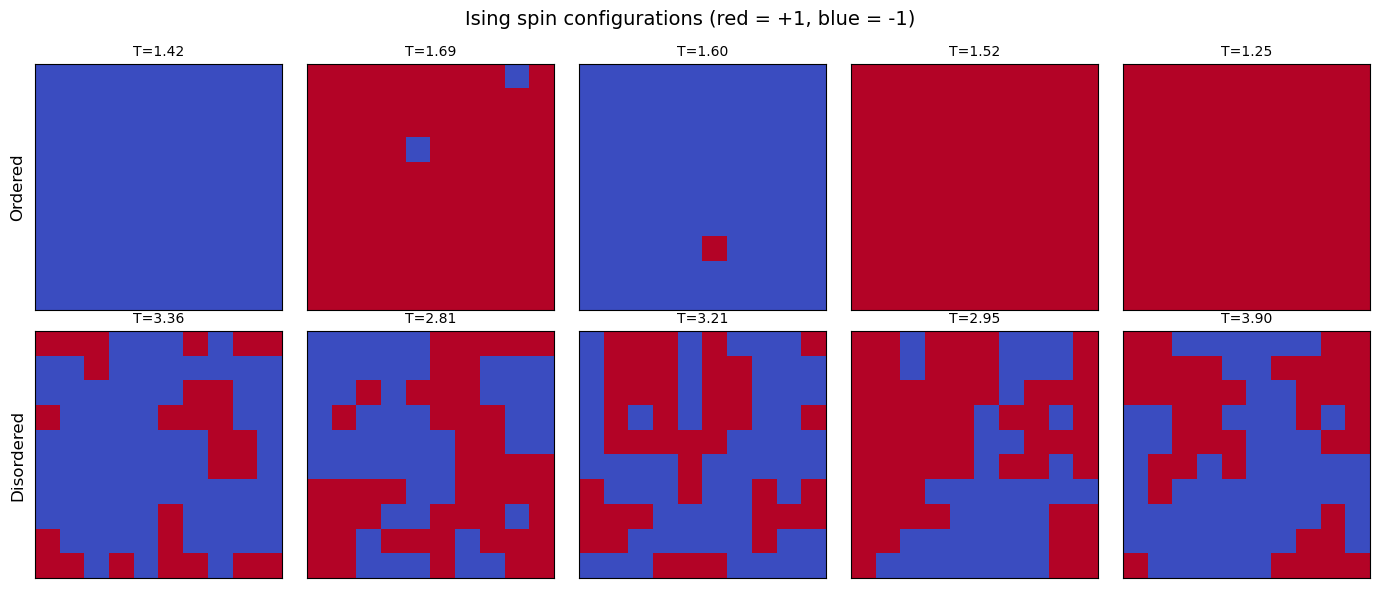

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for i, idx in enumerate(np.where(y_ising == 0)[0][:5]):
    axes[0, i].imshow(X_ising[idx].reshape(10, 10), cmap='coolwarm', vmin=-1, vmax=1)
    axes[0, i].set_title(f'T={T_ising[idx]:.2f}', fontsize=10)
    axes[0, i].set_xticks([]); axes[0, i].set_yticks([])
axes[0, 0].set_ylabel('Ordered', fontsize=12)

for i, idx in enumerate(np.where(y_ising == 1)[0][:5]):
    axes[1, i].imshow(X_ising[idx].reshape(10, 10), cmap='coolwarm', vmin=-1, vmax=1)
    axes[1, i].set_title(f'T={T_ising[idx]:.2f}', fontsize=10)
    axes[1, i].set_xticks([]); axes[1, i].set_yticks([])
axes[1, 0].set_ylabel('Disordered', fontsize=12)

fig.suptitle('Ising spin configurations (red = +1, blue = -1)', fontsize=14)
plt.tight_layout()
plt.show()

---
## Your tasks (~10 min)

Work with your partner on the following:

**1.** Split the data into train/test sets (70/30).

**2.** Fit a `LogisticRegression` classifier and report the test accuracy.

**3.** Compute the **mean magnetization** for each configuration:
$$M = \frac{1}{N_{\text{spins}}} \sum_i s_i$$
This is just `X_ising.mean(axis=1)`.

**4.** Plot a histogram of $M$, colored by the true phase label (ordered vs disordered). Use `alpha=0.5` so you can see both distributions.

**5.** Discuss with your partner:
- Is the accuracy what you expected? Why or why not?
- What does the histogram tell you about why the linear classifier struggles?
- Can you think of a simple transformation of $M$ that would make the problem easier?

Logistic regression test accuracy: 0.6625


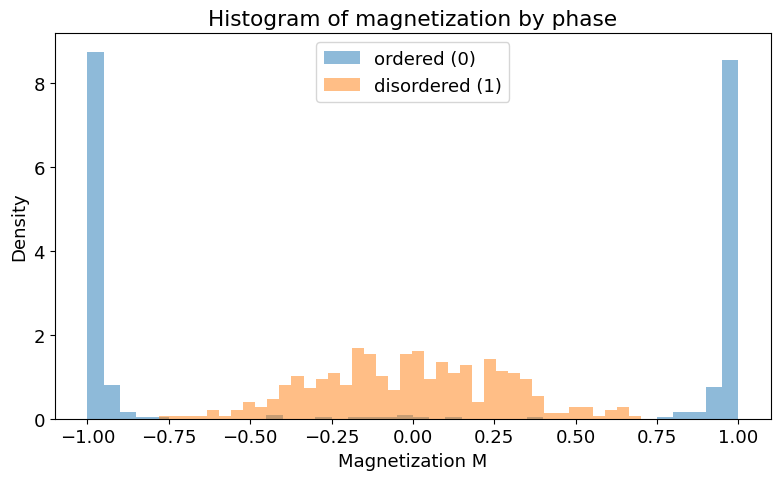

M mean for ordered: -0.0106
M mean for disordered: -0.0138


In [22]:
# Task 1: train/test split (70/30)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_ising, y_ising, test_size=0.3, random_state=0, stratify=y_ising
)

# Task 2: fit logistic regression and report test accuracy
clf = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=0)
clf.fit(X_tr, y_tr)
test_acc = clf.score(X_te, y_te)
print(f"Logistic regression test accuracy: {test_acc:.4f}")

# Task 3: mean magnetization
M = X_ising.mean(axis=1)

# Task 4: histogram of M by true label
plt.figure(figsize=(8, 5))
plt.hist(M[y_ising == 0], bins=40, alpha=0.5, label='ordered (0)', color='tab:blue', density=True)
plt.hist(M[y_ising == 1], bins=40, alpha=0.5, label='disordered (1)', color='tab:orange', density=True)
plt.xlabel('Magnetization M')
plt.ylabel('Density')
plt.title('Histogram of magnetization by phase')
plt.legend()
plt.tight_layout()
plt.show()

# Optional: quick stats
print("M mean for ordered:", np.round(M[y_ising == 0].mean(), 4))
print("M mean for disordered:", np.round(M[y_ising == 1].mean(), 4))